# Local Topology Validation

This notebook inspects the locked validation pass for the local-neighborhood topology result. The confirmatory candidate is fixed before evaluation: top-correlated market neighborhoods with `k=20`, graph thresholds inherited from the rescue sweep, and logistic regression as the downstream model.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUT = PROJECT / "data" / "processed"
RESULTS = OUT / "local_topology_validation_results.csv"
PREDICTIONS = OUT / "local_topology_validation_predictions.parquet"
SUMMARY = OUT / "local_topology_validation_summary.md"
PLACEBOS = OUT / "local_topology_validation_placebos.csv"
ABLATION = OUT / "local_topology_validation_ablation.csv"
BOOTSTRAP = OUT / "local_topology_validation_bootstrap.csv"
RESULTS

PosixPath('/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/local_topology_validation_results.csv')

## Optional Full Run

Leave `RUN_FULL_VALIDATION = False` unless you want to recompute all folds.

In [2]:
RUN_FULL_VALIDATION = False

if RUN_FULL_VALIDATION:
    from local_topology_validation import run_all

    run_all(
        PROJECT / "data" / "processed" / "candidate_universe_markets.parquet",
        PROJECT / "data" / "processed" / "prices_long.parquet",
        PROJECT / "data" / "processed" / "universe_b_macro_crypto_panel.parquet",
        OUT,
    )

In [3]:
results = pd.read_csv(RESULTS)
predictions = pd.read_parquet(PREDICTIONS)
placebos = pd.read_csv(PLACEBOS)
ablation = pd.read_csv(ABLATION)
bootstrap = pd.read_csv(BOOTSTRAP)
print(SUMMARY.read_text())
results.head()

LOCAL TOPOLOGY VALIDATION SUMMARY

Locked candidate:
- method: top_corr
- k: 20
- locked holdout fold: 17
- graph thresholds: 0.3, 0.5, 0.7

Overall performance:
- PCA-only log loss: 0.162077
- local topology log loss: 0.138709
- log loss gain vs PCA: +0.023368
- PCA-only Brier: 0.044367
- local topology Brier: 0.036362
- Brier gain vs PCA: +0.008005
- folds improved: log loss 12/17, Brier 14/17

Locked holdout:
- log loss gain vs PCA: +0.040370
- Brier gain vs PCA: +0.004595
- clears meaningful thresholds: yes

Placebo and leakage checks:
- beats all valid placebos: yes
- invalid test-period topology explicitly used test timestamps: yes
- invalid test-period topology log loss: 0.155145
- invalid test-period topology outperforms valid locked topology: no
- timestamp-within-market and future-shift placebos: not applicable because locked topology features are fold-static market features

Ablation and interpretation:
- beats simple neighborhood controls: no
- topology still helps after co

,fold,model,feature_set,category,is_confirmatory,is_valid_placebo,is_leakage_control,slice_type,slice_value,n_obs,brier,log_loss,avg_pred,avg_actual,auc
0,1,market_probability,market_probability,baseline,False,False,False,overall,overall,14850,0.071043,0.237257,0.179406,0.086532,0.915515
1,1,market_probability,market_probability,baseline,False,False,False,broad_domain,crypto,5721,0.102927,0.328372,0.232716,0.000000,NaN
2,1,market_probability,market_probability,baseline,False,False,False,broad_domain,macro,9129,0.051062,0.180157,0.145997,0.140760,0.967171
3,1,market_probability,market_probability,baseline,False,False,False,broad_family,crypto_btc,3112,0.103830,0.317257,0.219733,0.000000,NaN
4,1,market_probability,market_probability,baseline,False,False,False,broad_family,crypto_eth,1937,0.130053,0.409827,0.288019,0.000000,NaN


## Overall Model Ranking

In [4]:
overall = (
    results[results["slice_type"].eq("overall")]
    .groupby(["model", "feature_set", "category", "is_confirmatory", "is_valid_placebo", "is_leakage_control"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), auc=("auc", "mean"))
    .sort_values("log_loss")
)
overall

,model,feature_set,category,is_confirmatory,is_valid_placebo,is_leakage_control,folds,n_obs,log_loss,brier,auc
11,topology_plus_controls,top_corr_k20_topology_controls,ablation,False,False,False,17,282976,0.128669,0.034443,0.958828
1,controls_only,top_corr_k20_controls,ablation,False,False,False,17,282976,0.135540,0.036162,0.949246
4,local_topology_locked,top_corr_k20,confirmatory,True,False,False,17,282976,0.138709,0.036362,0.947098
7,placebo_random_neighborhood,random_k20,placebo,False,True,False,17,282976,0.148115,0.040768,0.934155
10,sensitivity_top_corr_k40,top_corr_k40,sensitivity,False,False,False,17,282976,0.149116,0.039636,0.940908
3,invalid_test_period_topology,top_corr_k20_test_corr,leakage_control,False,False,True,17,282976,0.155145,0.041231,0.937609
9,sensitivity_top_corr_k10,top_corr_k10,sensitivity,False,False,False,17,282976,0.155775,0.041265,0.941852
2,edge_density_only,top_corr_k20_edge_density,ablation,False,False,False,17,282976,0.156865,0.043178,0.938583
6,pca_only,pca,baseline,False,False,False,17,282976,0.162077,0.044367,0.940834
8,placebo_shuffle_market_within_timestamp,top_corr_k20,placebo,False,True,False,17,282976,0.162180,0.044345,0.939690


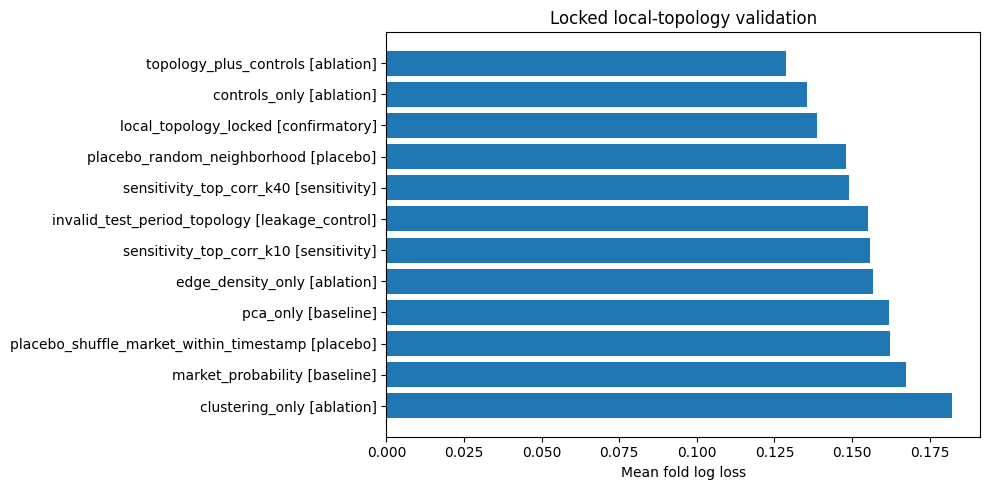

In [5]:
plot_df = overall.head(12).sort_values("log_loss")
fig, ax = plt.subplots(figsize=(10, 5))
labels = plot_df["model"] + " [" + plot_df["category"] + "]"
ax.barh(labels, plot_df["log_loss"])
ax.set_xlabel("Mean fold log loss")
ax.set_title("Locked local-topology validation")
ax.invert_yaxis()
plt.tight_layout()

## Fold-Level Deltas vs PCA

In [6]:
fold_overall = results[results["slice_type"].eq("overall")]
pca = fold_overall[fold_overall["model"].eq("pca_only")][["fold", "log_loss", "brier"]].rename(columns={"log_loss": "pca_log_loss", "brier": "pca_brier"})
deltas = fold_overall.merge(pca, on="fold", how="left")
deltas["delta_log_loss_vs_pca"] = deltas["log_loss"] - deltas["pca_log_loss"]
deltas["delta_brier_vs_pca"] = deltas["brier"] - deltas["pca_brier"]
deltas[deltas["model"].isin(["local_topology_locked", "controls_only", "topology_plus_controls", "placebo_shuffle_market_within_timestamp", "placebo_random_neighborhood"])].sort_values(["model", "fold"])

,fold,model,feature_set,category,is_confirmatory,is_valid_placebo,is_leakage_control,slice_type,slice_value,n_obs,brier,log_loss,avg_pred,avg_actual,auc,pca_log_loss,pca_brier,delta_log_loss_vs_pca,delta_brier_vs_pca
3,1,controls_only,top_corr_k20_controls,ablation,False,False,False,overall,overall,14850,0.032264,0.137191,0.106805,0.086532,0.914215,0.200325,0.059720,-0.063135,-0.027456
15,2,controls_only,top_corr_k20_controls,ablation,False,False,False,overall,overall,17934,0.029310,0.120156,0.080149,0.074941,0.944153,0.185151,0.053140,-0.064995,-0.023830
27,3,controls_only,top_corr_k20_controls,ablation,False,False,False,overall,overall,18204,0.020599,0.086947,0.077069,0.073830,0.977132,0.157503,0.045172,-0.070557,-0.024573
39,4,controls_only,top_corr_k20_controls,ablation,False,False,False,overall,overall,18492,0.028105,0.099411,0.071457,0.072842,0.977188,0.138853,0.038699,-0.039442,-0.010595
51,5,controls_only,top_corr_k20_controls,ablation,False,False,False,overall,overall,20281,0.020455,0.085073,0.067637,0.066269,0.968752,0.143797,0.040438,-0.058724,-0.019983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,13,topology_plus_controls,top_corr_k20_topology_controls,ablation,False,False,False,overall,overall,15813,0.044300,0.146863,0.118882,0.101246,0.967533,0.157447,0.044516,-0.010584,-0.000217
160,14,topology_plus_controls,top_corr_k20_topology_controls,ablation,False,False,False,overall,overall,11444,0.056277,0.179934,0.104470,0.117441,0.973812,0.182226,0.053588,-0.002292,0.002690
172,15,topology_plus_controls,top_corr_k20_topology_controls,ablation,False,False,False,overall,overall,11427,0.048949,0.163065,0.108219,0.117616,0.967317,0.168704,0.046095,-0.005639,0.002853
184,16,topology_plus_controls,top_corr_k20_topology_controls,ablation,False,False,False,overall,overall,8964,0.044192,0.181347,0.102185,0.122044,0.943389,0.199735,0.048882,-0.018388,-0.004690


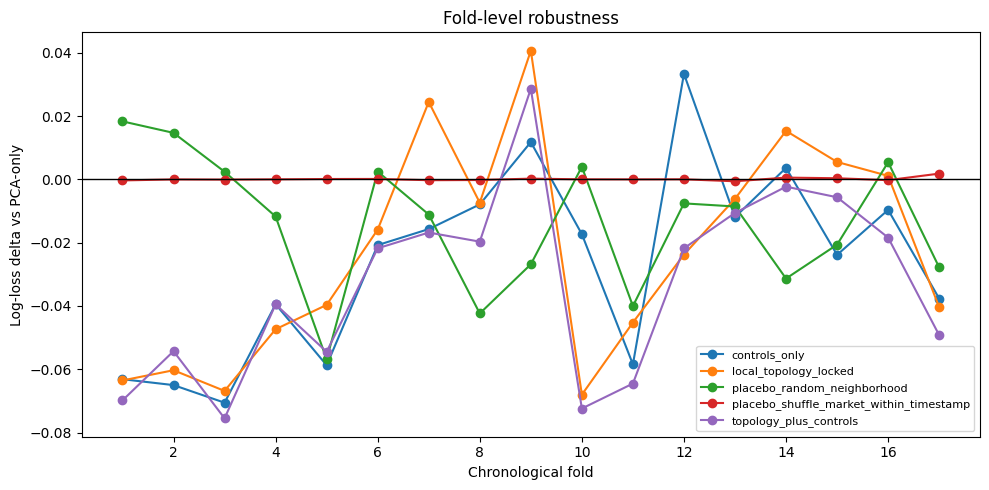

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for model, group in deltas[deltas["model"].isin(["local_topology_locked", "controls_only", "topology_plus_controls", "placebo_shuffle_market_within_timestamp", "placebo_random_neighborhood"])].groupby("model"):
    ax.plot(group["fold"], group["delta_log_loss_vs_pca"], marker="o", label=model)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Chronological fold")
ax.set_ylabel("Log-loss delta vs PCA-only")
ax.set_title("Fold-level robustness")
ax.legend(fontsize=8)
plt.tight_layout()

## Placebos and Ablations

In [8]:
placebo_overall = placebos[placebos["slice_type"].eq("overall")]
placebo_overall.groupby(["model", "feature_set", "category", "is_valid_placebo", "is_leakage_control"], as_index=False).agg(folds=("fold", "nunique"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), n_obs=("n_obs", "sum")).sort_values("log_loss")

,model,feature_set,category,is_valid_placebo,is_leakage_control,folds,log_loss,brier,n_obs
1,placebo_random_neighborhood,random_k20,placebo,True,False,17,0.148115,0.040768,282976
0,invalid_test_period_topology,top_corr_k20_test_corr,leakage_control,False,True,17,0.155145,0.041231,282976
2,placebo_shuffle_market_within_timestamp,top_corr_k20,placebo,True,False,17,0.162180,0.044345,282976


In [9]:
ablation_overall = ablation[ablation["slice_type"].eq("overall")]
ablation_overall.groupby(["model", "feature_set"], as_index=False).agg(folds=("fold", "nunique"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), n_obs=("n_obs", "sum")).sort_values("log_loss")

,model,feature_set,folds,log_loss,brier,n_obs
3,topology_plus_controls,top_corr_k20_topology_controls,17,0.128669,0.034443,282976
1,controls_only,top_corr_k20_controls,17,0.135540,0.036162,282976
2,edge_density_only,top_corr_k20_edge_density,17,0.156865,0.043178,282976
0,clustering_only,top_corr_k20_clustering,17,0.182138,0.051052,282976


## Bootstrap Confidence Intervals

In [10]:
bootstrap

,candidate,baseline,cluster,mean_log_loss_gain,ci_low,ci_high,n_units
0,local_topology_locked,pca_only,row,0.024257,0.023420,0.025144,282976
1,local_topology_locked,pca_only,market_id,0.024257,0.003761,0.045055,105
2,local_topology_locked,pca_only,timestamp,0.024257,0.023395,0.025279,5712


## Interpretation

The locked local-topology candidate clears the predefined holdout thresholds and beats valid placebos. The result should still be interpreted carefully: simple neighborhood controls are competitive, but adding topology to those controls improves over controls alone. That supports a paper framing where topology is a local-neighborhood enhancement rather than a standalone replacement for PCA.